In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import os



In [29]:
os.chdir('/Users/ericzhang/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/DISSERTATION/project 3 - contrastive la/Data for Eric/LPS 246 Abema-Nutlin')
adata = sc.read_h5ad("standard_adata.h5ad")
X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
df_X = pd.DataFrame(X, index=adata.obs.index, columns=adata.var.index)
#print(df_X.shape)


In [31]:
treatment_col = "dose"  

# Current feature names
feature_names = df_X.columns

# Filter
filtered_features = [
    col for col in feature_names
    if "total_nuc_protein" not in col
    and "nuc_cyto_ratio" not in col
    and not (col.startswith("R") and col.endswith("DNA_nuc_mean") and col != "R0_DNA_nuc_mean")
        and not (col.startswith("R") and col.endswith("DNA_ring_mean") and col != "R0_DNA_ring_mean")
    #and "pRB_rB_ratio" not in col
]

df_filtered = df_X[filtered_features]

X_all = np.array(df_filtered)

dose_strings = adata.obs[treatment_col].astype(str).tolist()
print(set(dose_strings))

# Masks
is_control = np.array([s == "0" for s in dose_strings])
is_nm      = np.array([s.lower().endswith("nm") for s in dose_strings])
is_um      = np.array([s.lower().endswith("um") for s in dose_strings])

mask_nm = is_control | is_nm
mask_um = is_control | is_um

# Split X
X_nm = X_all[mask_nm]
X_um = X_all[mask_um]

# --- Helper to parse doses with unit conversion ---
def parse_dose(s):
    if s == "0":
        return 0.0
    val_str, unit = s.split()
    val = float(val_str)
    if unit.lower() == "nm":
        return np.log(val + 1.0)
    elif unit.lower() == "um":
        return np.log(val * 1000.0 + 1.0)  # convert µM → nM
    else:
        raise ValueError(f"Unknown unit: {unit}")

# Build Z arrays
Z_nm = np.array([parse_dose(s) for s, m in zip(dose_strings, mask_nm) if m])
Z_um = np.array([parse_dose(s) for s, m in zip(dose_strings, mask_um) if m])

print("nm cohort:", X_nm.shape, Z_nm.shape)
print("um cohort:", X_um.shape, Z_um.shape)
print("Z_nm range:", Z_nm.min(), Z_nm.max())
print("Z_um range:", Z_um.min(), Z_um.max())


{'1 uM', '250 nM', '0', '500 nM', '10 nM', '25 nM', '10 uM', '5 uM', '50 nM', '100 nM'}
nm cohort: (138283, 39) (138283,)
um cohort: (65832, 39) (65832,)
Z_nm range: 0.0 6.2166061010848646
Z_um range: 0.0 9.210440366976517


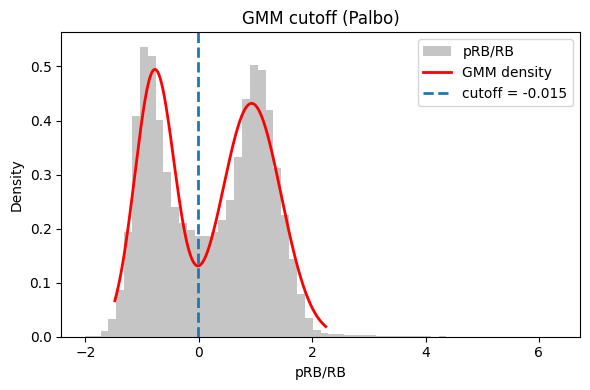

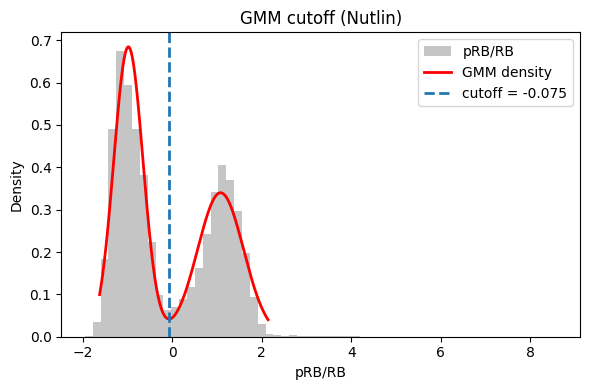

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler


def gmm_valley_cutoff(values_1d, n_components=2, plot_title=None):
    """Fit GMM on 1D values, return lowest-density point between the two component means."""
    vals = pd.Series(values_1d).dropna().to_numpy()
    if vals.size < 10:
        raise ValueError("Not enough finite values to fit GMM.")
    gmm = GaussianMixture(n_components=n_components, random_state=0)
    gmm.fit(vals.reshape(-1, 1))
    x_grid = np.linspace(np.nanpercentile(vals, 0.5),
                         np.nanpercentile(vals, 99.5), 2000).reshape(-1, 1)
    density = np.exp(gmm.score_samples(x_grid))
    means = np.sort(gmm.means_.flatten())
    mid_mask = (x_grid.flatten() >= means[0]) & (x_grid.flatten() <= means[1])
    if not np.any(mid_mask):
        valley_x = x_grid.flatten()[np.argmin(density)]
    else:
        mid_x = x_grid.flatten()[mid_mask]
        mid_d = density[mid_mask]
        valley_x = mid_x[np.argmin(mid_d)]

    # optional plot
    if plot_title is not None:
        plt.figure(figsize=(6,4))
        plt.hist(vals, bins=60, density=True, alpha=0.45, color="gray", label="pRB/RB")
        plt.plot(x_grid, density, 'r-', lw=2, label="GMM density")
        plt.axvline(valley_x, color="tab:blue", ls="--", lw=2, label=f"cutoff = {valley_x:.3f}")
        plt.xlabel("pRB/RB"); plt.ylabel("Density"); plt.title(plot_title)
        plt.legend(); plt.tight_layout(); plt.show()

    return float(valley_x)

# --- Compute per-cohort cutoffs ---

ratio_nm = df_X.loc[mask_nm, "pRB_rB_ratio"]
ratio_um = df_X.loc[mask_um, "pRB_rB_ratio"]

valley_x_nm = gmm_valley_cutoff(ratio_nm, plot_title="GMM cutoff (Palbo)")
valley_x_um = gmm_valley_cutoff(ratio_um, plot_title="GMM cutoff (Nutlin)")


In [33]:

# --- Subset each cohort by its own cutoff ---
nm_keep = (ratio_nm.values > valley_x_nm)
um_keep = (ratio_um.values > valley_x_um)


print("Before cutoff -> nm:", X_nm.shape, Z_nm.shape,
      "| um:", X_um.shape, Z_um.shape)

X_nm_sub = X_nm[nm_keep]
Z_nm_sub = Z_nm[nm_keep]


X_um_sub = X_um[um_keep]
Z_um_sub = Z_um[um_keep]

print("After cutoff -> nm:", X_nm_sub.shape, Z_nm_sub.shape,
      "| um:", X_um_sub.shape, Z_um_sub.shape)



Before cutoff -> nm: (138283, 39) (138283,) | um: (65832, 39) (65832,)
After cutoff -> nm: (76647, 39) (76647,) | um: (28552, 39) (28552,)


In [35]:
# ----- helpers -----
def _second_moment(X_group, center):
    n_g = X_group.shape[0]
    if n_g == 0:
        raise ValueError("Encountered an empty group.")
    if center:
        Xc = (X_group - X_group.mean(axis=0, keepdims=True))#/X.std(0)
        return (Xc.T @ Xc) / n_g
    else:
        return (X_group.T @ X_group) / n_g

def compute_CLA_matrix(X, Z, center):
    X = np.asarray(X); Z = np.asarray(Z)
    ctrl = (Z == 0)
    trt  = (Z > 0)

    Sigma0 = _second_moment(X[ctrl], center=center)
    z_treated = Z[trt]
    X_treated = X[trt]
    uniq = np.unique(z_treated)

    p = X.shape[1]
    n_plus = float(trt.sum())
    T = np.zeros((p, p), dtype=float)
    for z_val in uniq:
        idx = (z_treated == z_val)
        n_z = float(idx.sum())
        print(n_z)
        Sigma_z = _second_moment(X_treated[idx], center=center)
        T += (Sigma_z - Sigma0) / z_val
    T *= 1 / n_plus

    evals, evecs = np.linalg.eigh(T)
    order = np.argsort(evals)[::-1]
    return T, evals[order], evecs[:, order]

# --------- run CLA ----------
T, evals, cla_vecs = compute_CLA_matrix(X_um_sub, Z_um_sub, center=True)

# --------- plotting toggle ---------
plot_second = True  # <<< set to False to plot only eigenvector 1

if plot_second:
    v_cla   = [cla_vecs[:, 0], cla_vecs[:, 1]]
    titles   = ["CLA eigenvector 1", "CLA eigenvector 2"]
    ylabels  = [True, False]   # only show feature names on the first
    ncols    = 2
else:
    v_cla   = [cla_vecs[:, 0]]
    titles   = ["CLA eigenvector 1"]
    ylabels  = [True]
    ncols    = 1

#v_cla = np.abs(v_cla)



8418.0
1071.0
37.0


z=6.909, n=8418
z=8.517, n=1071
z=9.210, n=37


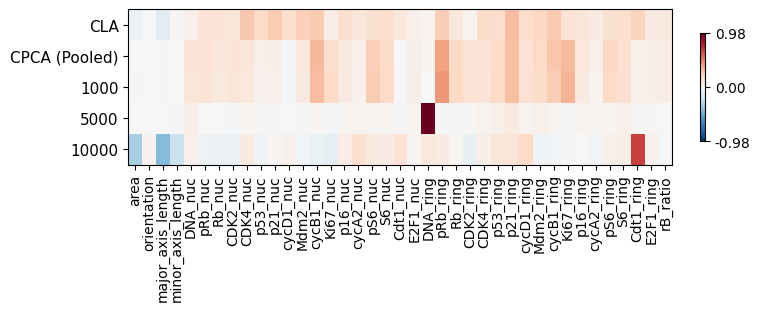

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# ----- helpers -----
def cov_mle(A):
    """(A - mean)^T (A - mean) / n  (p x p), symmetric."""
    A = np.asarray(A)
    A_c = A - A.mean(axis=0, keepdims=True)
    n = A.shape[0]
    return (A_c.T @ A_c) / n

def first_cpca_vector(X_fg, X_bg):
    """Return first eigenvector of cov(X_fg) - cov(X_bg)."""
    Sigma_fg = cov_mle(X_fg)
    Sigma_bg = cov_mle(X_bg)
    alpha = 1
    T = Sigma_fg - alpha * Sigma_bg
    evals, evecs = np.linalg.eigh(T)
    order = np.argsort(evals)[::-1]
    return evecs[:, order][:, 0]

scale = "um"   

if scale == "nm":
    X_sub, Z_sub = X_nm_sub, Z_nm_sub
    Y_bg = X_nm_sub[Z_nm_sub == 0]
elif scale == "um":
    X_sub, Z_sub = X_um_sub, Z_um_sub
    Y_bg = X_um_sub[Z_um_sub == 0]
else:
    raise ValueError("scale must be 'nm' or 'um'")

# ----- eigenvectors -----
cols, labels = [], []

# 1) CLA
v_cla_vec = np.asarray(v_cla[0]).reshape(-1)
cols.append(v_cla_vec)
labels.append("CLA")

# 2) CPCA pooled (all treated)
X_fg_all = X_sub[Z_sub != 0]
if X_fg_all.shape[0] >= 2:
    v_cpca_all = first_cpca_vector(X_fg_all, Y_bg)
    cols.append(v_cpca_all)
    labels.append("CPCA (Pooled)")

# 3) CPCA per-dose
unique_nonzero_z = np.sort(np.unique(Z_sub[Z_sub != 0]))
for z in unique_nonzero_z:
    X_fg_z = X_sub[Z_sub == z]
    print(f"z={z:.3f}, n={X_fg_z.shape[0]}")
    if X_fg_z.shape[0] < 2:
        continue
    v_cpca_z = first_cpca_vector(X_fg_z, Y_bg)


    dose_val = int(np.round(np.exp(float(z)) - 1, 1))

    cols.append(v_cpca_z)
    labels.append(f"{dose_val}")

# ----- sign alignment to CLA -----
eigmat = np.stack(cols, axis=1)
ref = eigmat[:, 0].copy()
ref_norm = np.linalg.norm(ref)

for j in range(eigmat.shape[1]):
    col = eigmat[:, j]
    if ref_norm > 0:
        if np.dot(col, ref) < 0:
            eigmat[:, j] = -col
    else:
        idx = np.argmax(np.abs(col))
        if col[idx] < 0:
            eigmat[:, j] = -col

# ----- heatmap -----
#eigmat = np.abs(eigmat)

# ---- Transpose BEFORE plotting ----
eigmat_plot = eigmat.T    # shape becomes (n_labels, n_features)

vabs = eigmat_plot.max()
vmin = eigmat_plot.min()
vmin, vmax = vmin, vabs

fig, ax = plt.subplots(figsize=(7.5, 3), constrained_layout=True)

from matplotlib import colors

norm = colors.TwoSlopeNorm(
    vmin=-np.max(np.abs(eigmat_plot)),
    vcenter=0.0,
    vmax= np.max(np.abs(eigmat_plot))
)

img = ax.imshow(
    eigmat_plot,
    aspect='auto',
    cmap='RdBu_r',
    norm=norm
)



# ========== X-axis: features ==========
keep_whole = {"major_axis_length", "minor_axis_length"}

simplified_features = []
for f in filtered_features:

    # 1. Drop trailing "_mean"
    if f.endswith("_mean"):
        f = f[:-5]   # remove the 5 characters in "_mean"

    # 2. Keep whole name for special cases
    if f in keep_whole:
        simplified_features.append(f)
        continue

    # 3. Otherwise keep portion after first underscore (if exists)
    if "_" in f:
        simplified_features.append(f.split("_", 1)[1])
    else:
        simplified_features.append(f)


ax.set_xticks(np.arange(len(simplified_features)))
ax.set_xticklabels(simplified_features, fontsize=10, rotation=90)

# ========== Y-axis: method labels ==========
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels, fontsize=11)

# ========== Colorbar ==========
abs_max = np.max(np.abs(eigmat_plot))

cbar = fig.colorbar(img, ax=ax, shrink=0.7)
cbar.set_ticks([-abs_max, 0, abs_max])
cbar.ax.set_yticklabels([f"{-abs_max:.2f}", "0.00", f"{abs_max:.2f}"])

# Increase readability
cbar.ax.tick_params(labelsize=10)

# save & show
out_path = "/Users/ericzhang/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/dissertation work/project 3 - contrastive la/nutlin_246_1_T.png"
#fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()


In [39]:
abs1 = abs(v_cla_vec)
abs2 = abs(v_cpca_all)
diff = abs1-abs2

mask = abs1 > abs2
simplified_features = np.array(simplified_features)
# -------------------------------------------------
# 2. Apply mask
# -------------------------------------------------
df_filtered = pd.DataFrame({
    "feature": simplified_features[mask],
    "eig1_abs": abs1[mask],
    "eig2_abs": abs2[mask],
    "diff": diff[mask]
})

# -------------------------------------------------
# 3. Sort by difference
# -------------------------------------------------
df_filtered_sorted = df_filtered.sort_values(by="diff", ascending=False)

# -------------------------------------------------
# 4. Top features
# -------------------------------------------------
top_k = 10
top_features = df_filtered_sorted.head(top_k)

print(top_features)

              feature  eig1_abs  eig2_abs      diff
7             p21_nuc  0.252318  0.059845  0.192473
20          Cdt1_ring  0.220631  0.051684  0.168948
5            CDK4_nuc  0.264908  0.116166  0.148741
6             p53_nuc  0.187301  0.048538  0.138763
8           cycD1_nuc  0.157594  0.020785  0.136809
9            Mdm2_nuc  0.236066  0.100078  0.135988
2   major_axis_length  0.111046  0.007790  0.103256
12           Cdt1_nuc  0.104814  0.001745  0.103068
10            p16_nuc  0.158812  0.098616  0.060196
11          cycA2_nuc  0.112443  0.053629  0.058815
